In [1]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Task 2 – Exploratory Data Analysis (EDA)

## E-Commerce Sales Dataset

**Objective:**  
To explore, clean, analyze and visualize the e-commerce sales dataset
in order to identify important patterns, trends and business insights.

### Dataset Overview
- Dataset: E-Commerce Sales
- Records: 1.1 Million
- Original Features: 7
- Analysis includes product, category, city, quantity, price and revenue.

## 1. Importing Required Libraries

The following Python libraries are used for data manipulation,
numerical analysis and data visualization.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Loading the Dataset

The e-commerce sales CSV file is loaded into a Pandas DataFrame
for further analysis.

In [6]:
df = pd.read_csv("ecommerce_sales_1.1_millions_records.csv")

In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)

Number of rows: 1100000
Number of columns: 7
Dataset shape: (1100000, 7)


## 4. Preview of the Dataset

The first five records are displayed to understand the structure
and contents of the dataset.

In [8]:
df.head()

,Order_ID,Product,Category,Quantity,Price,City,Date
0,ORD0000001,Smartphone,Electronics,3,13376,Jaipur,2026-05-31
1,ORD0000002,Bedsheet,Home & Living,5,1979,Bengaluru,2024-11-02
2,ORD0000003,Coffee Maker,Home Appliances,5,3061,Ahmedabad,2026-04-25
3,ORD0000004,Shoes,Footwear,3,1551,Nagpur,2026-08-08
4,ORD0000005,Shoes,Footwear,3,1537,Jaipur,2024-12-27


## 5. Last Records of the Dataset

The last five records are displayed to verify the end of the dataset.

In [9]:
df.tail()

,Order_ID,Product,Category,Quantity,Price,City,Date
1099995,ORD1099996,Mixer Grinder,Home Appliances,1,6255,Ahmedabad,2024-02-18
1099996,ORD1099997,T-Shirt,Clothing,5,1194,Kolkata,2026-01-15
1099997,ORD1099998,Wallet,Accessories,2,692,Hyderabad,2025-10-05
1099998,ORD1099999,Smartphone,Electronics,1,30440,Chennai,2026-02-12
1099999,ORD1100000,Shoes,Footwear,5,5501,Jaipur,2024-07-14


## 6. Dataset Information

This step checks column names, data types and the number of
non-null values in each column.

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1100000 entries, 0 to 1099999
Data columns (total 7 columns):
 #   Column    Non-Null Count    Dtype
---  ------    --------------    -----
 0   Order_ID  1100000 non-null  str  
 1   Product   1100000 non-null  str  
 2   Category  1100000 non-null  str  
 3   Quantity  1100000 non-null  int64
 4   Price     1100000 non-null  int64
 5   City      1100000 non-null  str  
 6   Date      1100000 non-null  str  
dtypes: int64(2), str(5)
memory usage: 58.7 MB


## 7. Statistical Summary

Descriptive statistics are calculated for the numerical columns
to understand their distribution and basic statistical properties.

In [11]:
df.describe()

,Quantity,Price
count,1.100000e+06,1.100000e+06
mean,2.999848e+00,1.006885e+04
std,1.413653e+00,1.711320e+04
min,1.000000e+00,1.500000e+02
25%,2.000000e+00,1.590000e+03
50%,3.000000e+00,3.220000e+03
75%,4.000000e+00,8.496000e+03
max,5.000000e+00,8.500000e+04


## 8. Missing Value Analysis

We check each column for missing or null values.

In [12]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Order_ID    0
Product     0
Category    0
Quantity    0
Price       0
City        0
Date        0
dtype: int64


### Insight

There are no missing values in any of the seven original columns.
Therefore, no missing-value treatment is required before performing
the main analysis.

## 9. Duplicate Record Analysis

Duplicate rows are checked to ensure that the dataset does not
contain repeated records.

In [13]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### Insight

The dataset contains no duplicate rows. Therefore, duplicate
records do not require removal.

## 10. Unique Value Analysis

The number of unique values in important categorical columns
is calculated to understand the variety of products, categories,
cities and orders.

In [14]:
print("Unique Orders:", df['Order_ID'].nunique())
print("Unique Products:", df['Product'].nunique())
print("Unique Categories:", df['Category'].nunique())
print("Unique Cities:", df['City'].nunique())

Unique Orders: 1100000
Unique Products: 20
Unique Categories: 9
Unique Cities: 20


## 11. Product-wise Order Analysis

We analyze the number of orders associated with each product
to identify the most frequently ordered products.

In [15]:
product_orders = df['Product'].value_counts()

print("Top 10 Products by Number of Orders:")
print(product_orders.head(10))

Top 10 Products by Number of Orders:
Product
Backpack         55323
Wallet           55307
Smart Watch      55264
Mixer Grinder    55204
Headphones       55162
Shoes            55096
Curtains         55093
Books            55053
Smartphone       55042
Jeans            55040
Name: count, dtype: int64


## 12. Top 10 Products by Orders

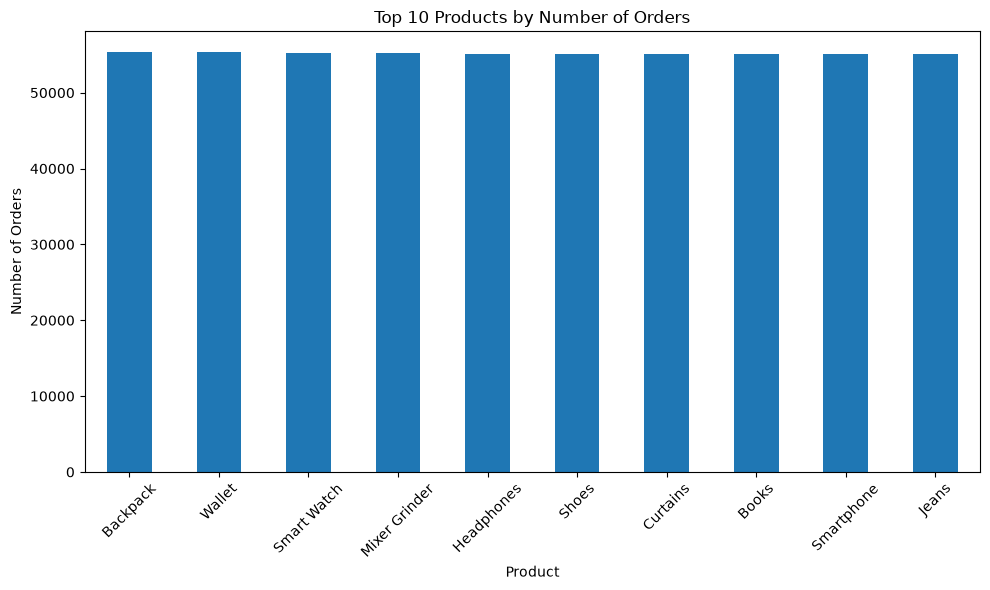

In [16]:
plt.figure(figsize=(10, 6))

df['Product'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Products by Number of Orders')
plt.xlabel('Product')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

Backpack has the highest number of orders, followed closely by
Wallet and Smart Watch among the top products.

The order counts are relatively close because the dataset contains
a large number of transactions distributed across multiple products.

## 13. Category-wise Order Analysis

We analyze the number of orders in each product category.

In [17]:
category_orders = df['Category'].value_counts()
print(category_orders)

Category
Electronics        275198
Clothing           164787
Accessories        110630
Home Appliances    110033
Footwear           110033
Home & Living      109973
Furniture          109394
Books               55053
Kitchen             54899
Name: count, dtype: int64


## 14. Orders by Category

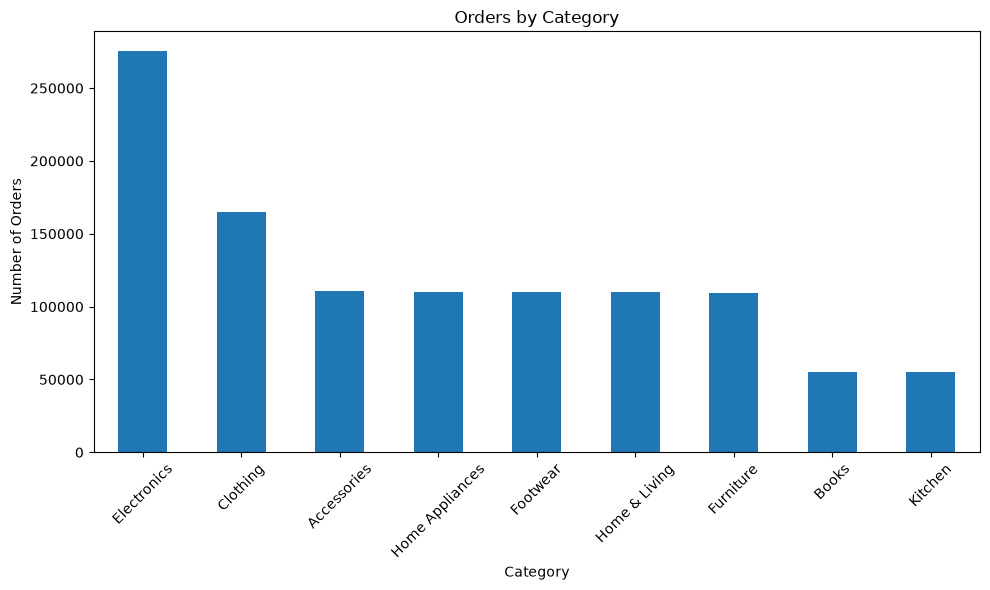

In [18]:
plt.figure(figsize=(10, 6))

category_orders.plot(kind='bar')

plt.title('Orders by Category')
plt.xlabel('Category')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

Electronics is the most frequently ordered category with 275,198
orders.

Clothing is the second-largest category with 164,787 orders.

Books and Kitchen have the lowest order volumes among the categories.

## 15. City-wise Order Analysis

We analyze order distribution across different cities to identify
cities with higher order volumes.

In [19]:
city_orders = df['City'].value_counts()

print("Top 10 Cities by Orders:")
print(city_orders.head(10))

Top 10 Cities by Orders:
City
Delhi        55357
Hyderabad    55233
Kochi        55232
Surat        55209
Gurugram     55198
Ahmedabad    55181
Rajkot       55147
Nagpur       55131
Vadodara     55124
Bhopal       54993
Name: count, dtype: int64


## 16. Top 10 Cities by Orders

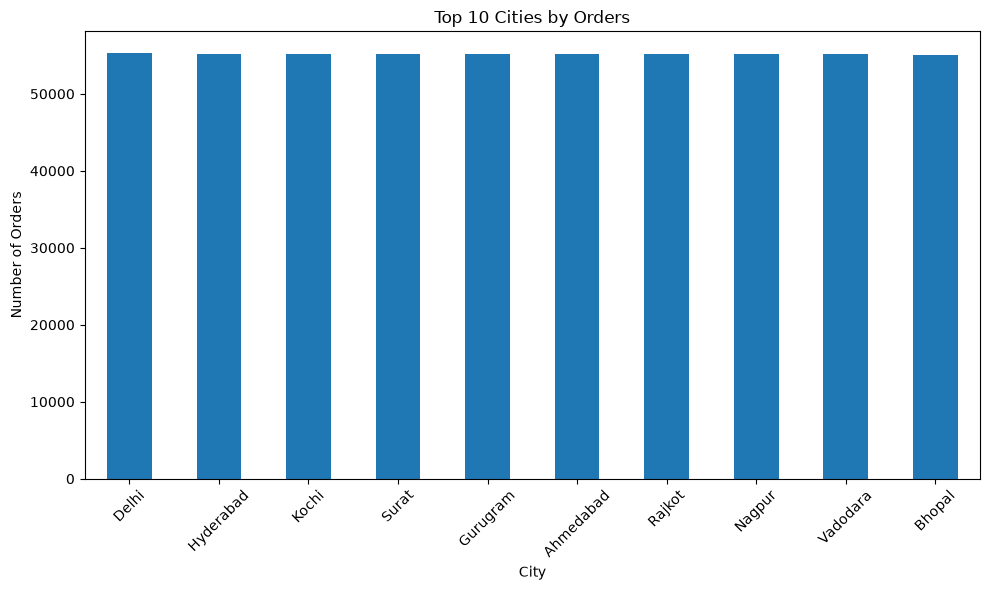

In [20]:
plt.figure(figsize=(10, 6))

city_orders.head(10).plot(kind='bar')

plt.title('Top 10 Cities by Orders')
plt.xlabel('City')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

Delhi has the highest number of orders among the cities, followed
by Hyderabad, Kochi and Surat.

The order distribution across cities is relatively balanced,
with no single city dominating the dataset.

## 17. Revenue Calculation

The dataset does not contain a direct revenue column.

Revenue is calculated using the formula:

Revenue = Quantity × Price

In [21]:
df['Revenue'] = df['Quantity']*df['Price']
df[['Quantity', 'Price', 'Revenue']].head()

,Quantity,Price,Revenue
0,3,13376,40128
1,5,1979,9895
2,5,3061,15305
3,3,1551,4653
4,3,1537,4611


## 18. Total Revenue

The total revenue generated across all transactions is calculated.

In [22]:
total_revenue = df['Revenue'].sum()

print("Total Revenue:", total_revenue)
print("Total Revenue (₹):", f"₹{total_revenue:,.0f}")

Total Revenue: 33284921501
Total Revenue (₹): ₹33,284,921,501


### Insight

The total calculated revenue from all 1.1 million transactions is:

**₹33,284,921,501**

This indicates a very large transaction volume across the
three-year period represented in the dataset.

## 19. Revenue by Category

Category-wise revenue is calculated to identify which categories
contribute the most to total revenue.

In [23]:
category_revenue = (
    df.groupby('Category')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

print(category_revenue)

Category
Electronics        25168365850
Furniture           2877418786
Home Appliances     1607495235
Clothing            1036972974
Footwear             841894562
Home & Living        610247395
Accessories          521980156
Kitchen              509142950
Books                111403593
Name: Revenue, dtype: int64


## 20. Category-wise Revenue Visualization

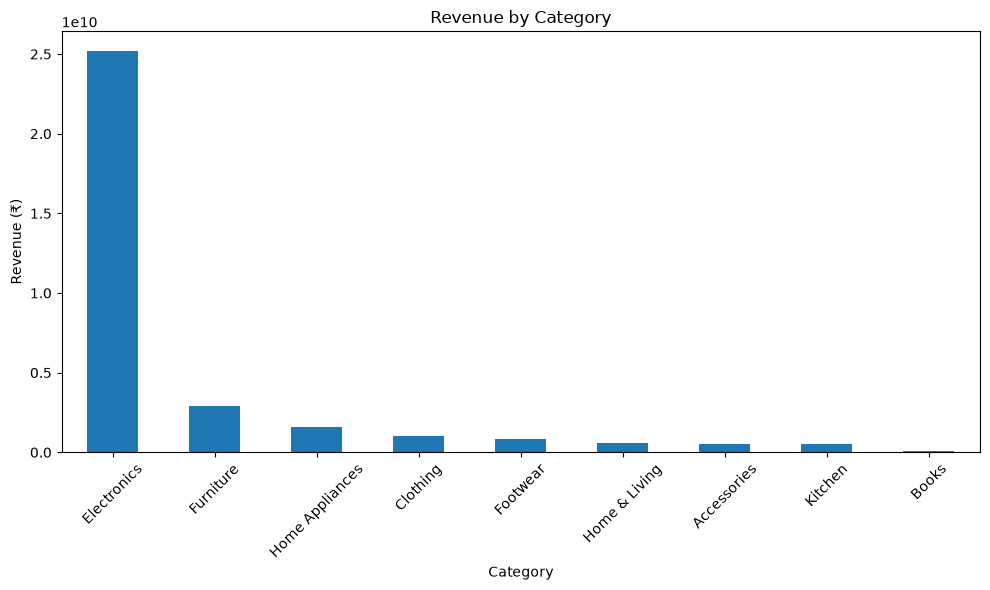

In [28]:
plt.figure(figsize=(10, 6))

category_revenue.plot(kind='bar')

plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

Electronics is the strongest revenue-generating category with
approximately ₹25.17 billion in revenue.

Furniture is the second-highest revenue-generating category with
approximately ₹2.88 billion.

Books generates the lowest revenue among the categories at
approximately ₹111.4 million.

This shows that Electronics is the primary contributor to overall
revenue.

## 21. Product-wise Revenue Analysis

Product-level revenue is analyzed to identify the products
that contribute the most to overall revenue.

In [31]:
product_revenue = (
    df.groupby('Product')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

print("Top 10 Products by Revenue:")
print(product_revenue.head(10))

Top 10 Products by Revenue:
Product
Laptop           10695629791
Smartphone        7226822179
Tablet            4546341105
Smart Watch       1640712353
Office Chair      1605309106
Study Table       1272109680
Headphones        1058860422
Coffee Maker       920473548
Mixer Grinder      687021687
Shoes              594475756
Name: Revenue, dtype: int64


## 22. Top 10 Products by Revenue

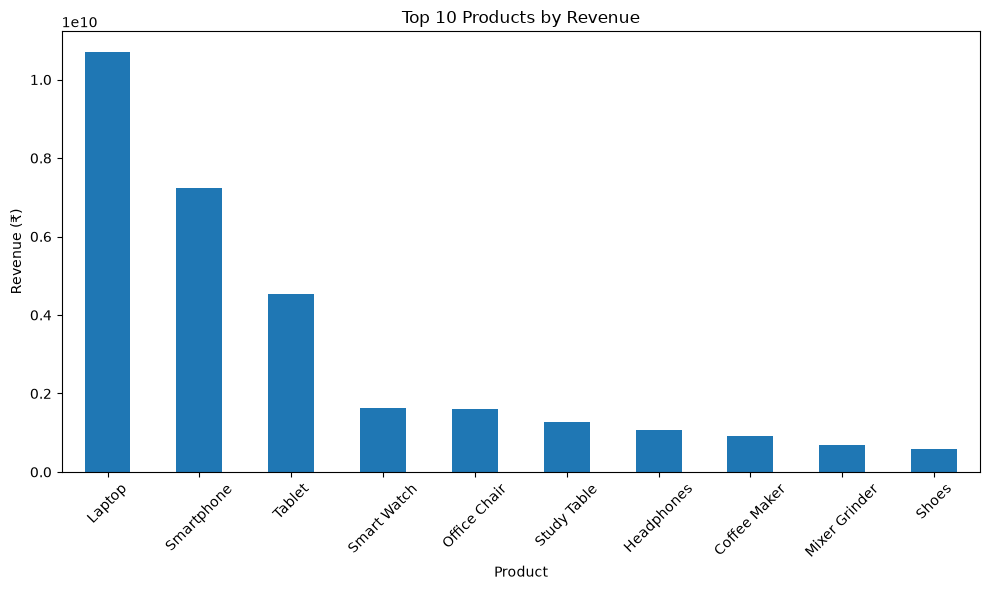

In [32]:
plt.figure(figsize=(10, 6))

product_revenue.head(10).plot(kind='bar')

plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

Laptop is the highest revenue-generating product with approximately
₹10.70 billion in revenue.

Smartphone is the second-highest revenue-generating product with
approximately ₹7.23 billion.

Tablet ranks third with approximately ₹4.55 billion.

The results show that high-value electronic products contribute
significantly to total revenue.

## 23. Quantity Analysis

We analyze the total quantity of products sold and identify the
products with the highest total quantity sold.

In [33]:
total_quantity = df['Quantity'].sum()

quantity_by_product = (
    df.groupby('Product')['Quantity']
    .sum()
    .sort_values(ascending=False)
)

print("Total Quantity Sold:", total_quantity)

print("\nTop 10 Products by Quantity Sold:")
print(quantity_by_product.head(10))

Total Quantity Sold: 3299833

Top 10 Products by Quantity Sold:
Product
Smartphone       166124
Headphones       165902
Wallet           165840
Backpack         165813
Smart Watch      165584
Mixer Grinder    165439
Shoes            165368
Books            165237
Curtains         165142
Jeans            165110
Name: Quantity, dtype: int64


### Insight

A total of **3,299,833 units** were sold across all transactions.

The quantity distribution helps identify products that have strong
sales volume independently of their price or revenue contribution.

## 24. Date Conversion

The Date column is converted from text format to Pandas datetime
format so that time-based analysis can be performed.

In [36]:
df['Date'] = pd.to_datetime(df['Date'])

print("Date conversion completed.")
print(df['Date'].dtype)

Date conversion completed.
datetime64[us]


## 25. Sales Date Range

We identify the earliest and latest transaction dates in the dataset.

In [38]:
print("Start Date:", df['Date'].min().date())
print("End Date:", df['Date'].max().date())

Start Date: 2024-01-01
End Date: 2026-08-16


### Insight

The dataset contains transactions from **1 January 2024** to
**16 August 2026**, covering more than two and a half years
of sales activity.

## 26. Monthly Revenue Analysis

Monthly revenue is calculated to identify sales trends over time.

In [39]:
monthly_revenue = (
    df.groupby(df['Date'].dt.to_period('M'))['Revenue']
    .sum()
)

monthly_revenue.head()

Date
2024-01    1069230242
2024-02    1019927703
2024-03    1067701964
2024-04    1026448409
2024-05    1065135520
Freq: M, Name: Revenue, dtype: int64

## 27. Monthly Revenue Trend

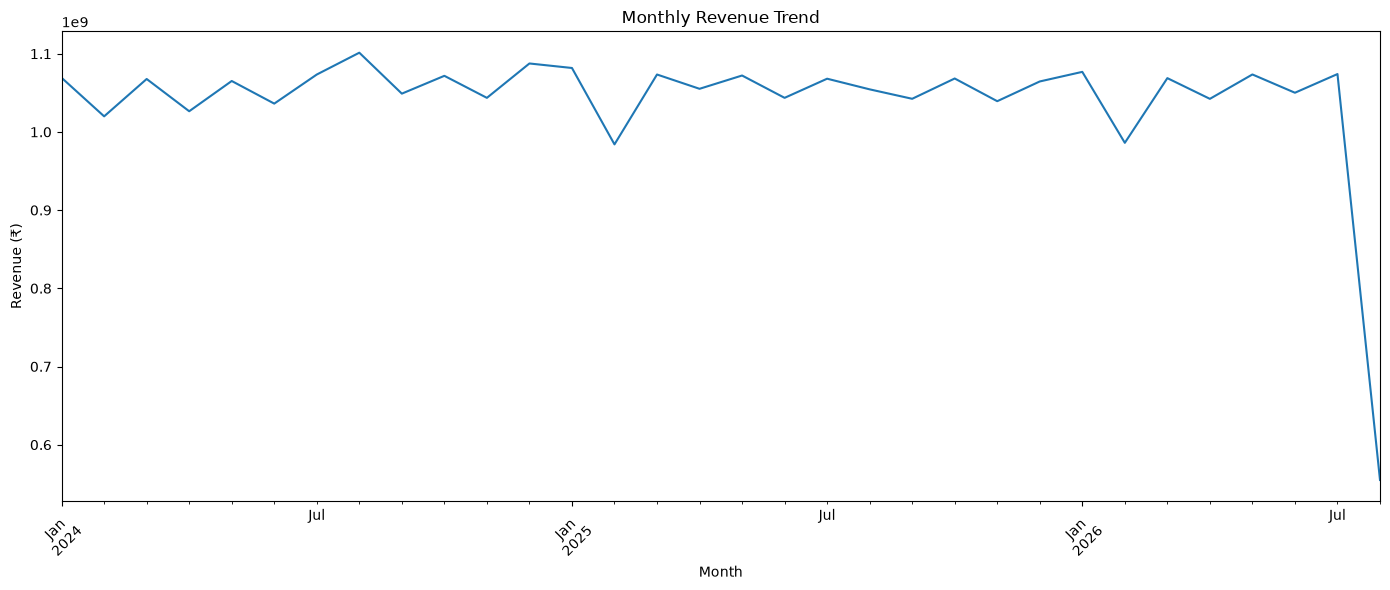

In [40]:
plt.figure(figsize=(14, 6))

monthly_revenue.plot()

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

Monthly revenue remains relatively strong throughout the dataset's
time period, with some month-to-month variation.

The highest-revenue month is **August 2024**, generating approximately
₹1.10 billion in revenue.

## 28. Year-wise Revenue Analysis

Revenue is grouped by year to compare overall annual performance.

In [41]:
yearly_revenue = (
    df.groupby(df['Date'].dt.year)['Revenue']
    .sum()
)

print(yearly_revenue)

Date
2024    12711219711
2025    12647228682
2026     7926473108
Name: Revenue, dtype: int64


## 29. Year-wise Revenue Visualization

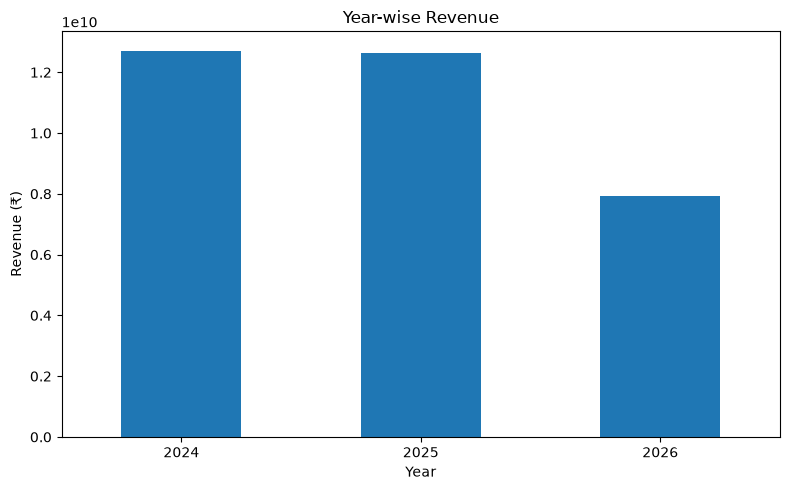

In [42]:
plt.figure(figsize=(8, 5))

yearly_revenue.plot(kind='bar')

plt.title('Year-wise Revenue')
plt.xlabel('Year')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Insight

Revenue generated by year:

- 2024: ₹12.71 billion
- 2025: ₹12.65 billion
- 2026: ₹7.93 billion

The 2024 and 2025 revenue levels are very similar.

The lower 2026 revenue should be interpreted carefully because
the dataset only contains transactions up to 16 August 2026,
so 2026 represents a partial year.

## 30. Correlation Analysis

Correlation analysis is performed to understand the relationship
between Quantity, Price and Revenue.

In [43]:
correlation = df[['Quantity', 'Price', 'Revenue']].corr()

correlation

,Quantity,Price,Revenue
Quantity,1.000000,0.002232,0.244875
Price,0.002232,1.000000,0.877840
Revenue,0.244875,0.877840,1.000000


## 31. Correlation Heatmap

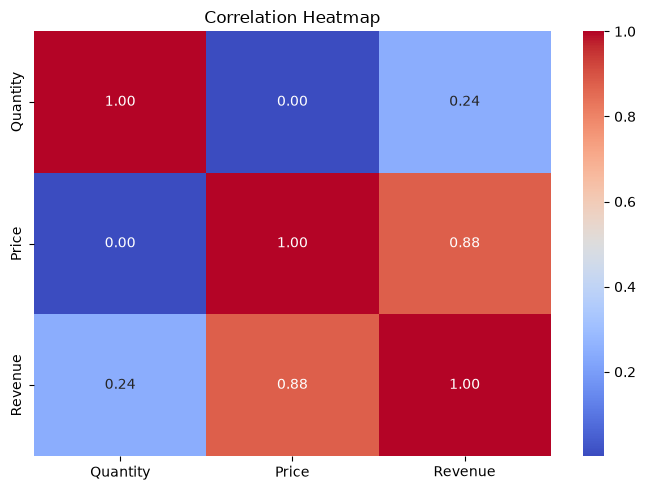

In [44]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Insight

Price and Revenue show a strong positive correlation of approximately
**0.88**.

Quantity and Revenue show a moderate positive correlation of
approximately **0.25**.

Quantity and Price have almost no linear correlation
(approximately **0.00**).

Since Revenue is calculated as Quantity × Price, the strong
relationship between Price and Revenue is expected.

## 32. Price Distribution

A histogram is used to understand the distribution of product prices.

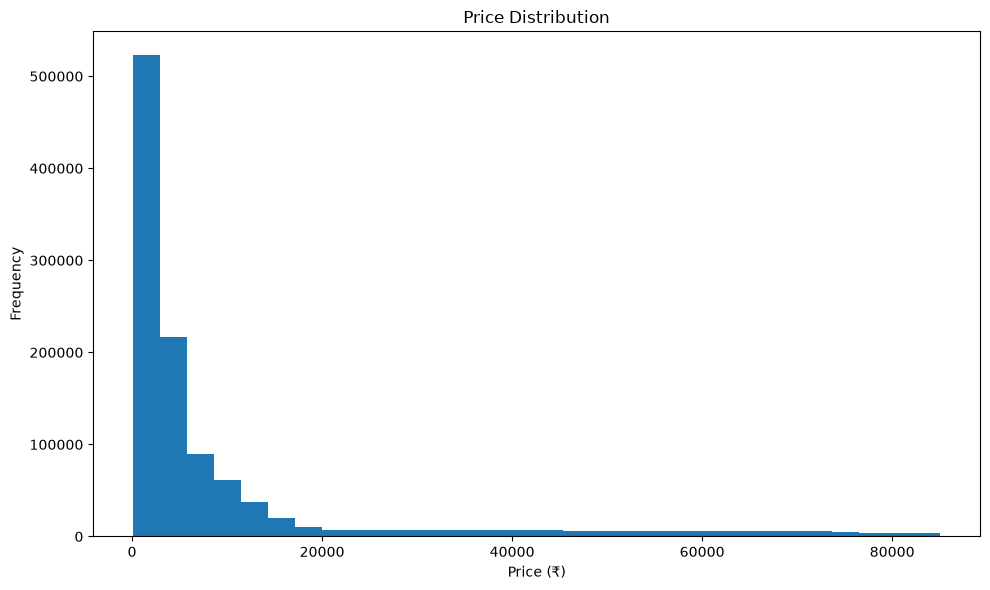

In [45]:
plt.figure(figsize=(10, 6))

plt.hist(df['Price'], bins=30)

plt.title('Price Distribution')
plt.xlabel('Price (₹)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Insight

Product prices range from ₹150 to ₹85,000.

The median price is approximately ₹3,220, while the mean price is
approximately ₹10,069.

The difference between the mean and median indicates that the
price distribution is influenced by higher-priced products.

## 33. Quantity Distribution

The distribution of quantities purchased per transaction is analyzed.

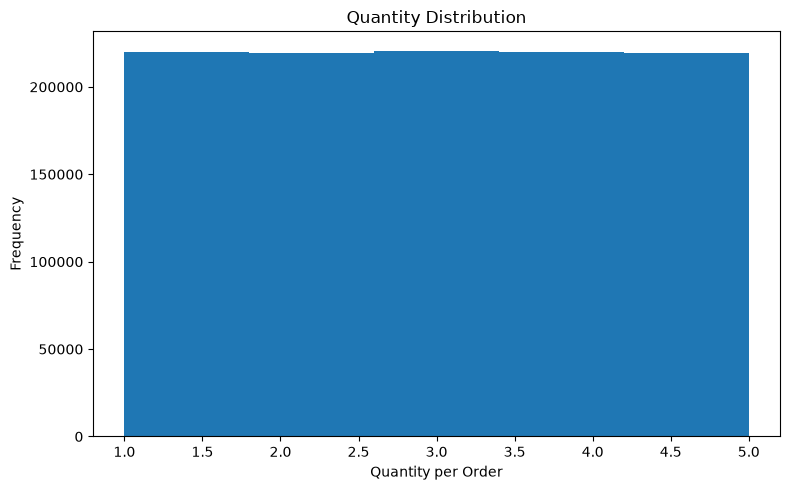

In [46]:
plt.figure(figsize=(8, 5))

plt.hist(df['Quantity'], bins=5)

plt.title('Quantity Distribution')
plt.xlabel('Quantity per Order')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Insight

The quantity per transaction ranges from 1 to 5 units.

The average quantity per transaction is approximately 3 units,
indicating that customers generally purchase multiple units per order.

# 34. Key EDA Findings

Based on the exploratory analysis, the following major findings
were identified:

1. The dataset contains 1.1 million e-commerce transactions
   and 7 original features.

2. There are no missing values and no duplicate records.

3. The dataset contains 20 unique products, 9 categories and
   20 cities.

4. Electronics is the category with the highest number of orders
   and is also the largest contributor to revenue.

5. Laptop is the highest revenue-generating product, followed by
   Smartphone and Tablet.

6. The total calculated revenue is ₹33,284,921,501.

7. A total of 3,299,833 units were sold across all transactions.

8. Delhi has the highest order count among the cities analyzed.

9. Sales data ranges from January 2024 to August 2026.

10. Price has a strong positive correlation with Revenue,
    while Quantity has a moderate positive correlation with Revenue.

11. The year 2026 has lower total revenue because the dataset
    contains only partial-year data through 16 August 2026.

# 35. Business Insights & Recommendations

### 1. Focus on Electronics
Electronics is the strongest category in terms of both order volume
and revenue. The business can prioritize inventory, promotions and
marketing for high-performing electronics.

### 2. Promote High-Value Products
Laptop, Smartphone and Tablet contribute substantially to revenue.
Targeted promotions and bundled offers can be considered for these
products.

### 3. Monitor City-wise Demand
Delhi and other high-order cities represent important markets.
Inventory and marketing strategies can be optimized according to
regional demand.

### 4. Analyze Pricing Strategy
The strong relationship between Price and Revenue indicates that
higher-priced products have a major influence on revenue generation.
Pricing and product mix should therefore be monitored carefully.

### 5. Consider Seasonal Trends
Monthly revenue analysis shows variation across months. Further
analysis can be performed to identify seasonal demand patterns
and plan promotional campaigns.

### 6. Interpret Partial-Year Data Carefully
The 2026 revenue is not directly comparable with full-year 2024
and 2025 because the available 2026 data ends on 16 August.

# 36. Conclusion

Exploratory Data Analysis provided a clear understanding of the
e-commerce sales dataset.

The analysis identified important patterns in products, categories,
cities, quantities, prices, revenue and sales trends over time.

Electronics emerged as the dominant revenue-generating category,
while Laptop was the highest revenue-generating product.

The analysis also confirmed that the dataset is complete, with no
missing or duplicate records.

Overall, the EDA provides useful insights that can support business
decisions related to product strategy, inventory management,
pricing and marketing.